# 🍎 Fruits & Vegetables AI – CV Block: Quantitative Evaluation

## Objective
Systematically evaluate the **CLIP Zero-Shot classifier** on a real-world image dataset
to measure accuracy, identify error patterns, and document model limitations.

## Why this matters
The main `cv_classification.ipynb` notebook only tested CLIP visually on 4 images.
This notebook adds a proper **quantitative evaluation** (accuracy, per-class metrics,
confusion matrix, error analysis) as required by the project rubric (Block 2C.5).

## Dataset
- **Source:** [Fruits and Vegetables Image Recognition (kritikseth, Kaggle)](https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition)
- **Type:** Real photographs (not synthetic) – 36 classes, train/test/validation split
- **Our use:** We evaluate only on the classes that overlap with our 24 app labels

## Setup (Google Colab)
1. Runtime → Change runtime type → **T4 GPU** (recommended)
2. Upload `archive.zip` (downloaded from Kaggle) via the file panel on the left
3. Run all cells top to bottom

## 1. Install & Import

In [6]:
!pip install -q transformers torch pillow scikit-learn matplotlib seaborn

import os
import zipfile
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

random.seed(42)
np.random.seed(42)
print('✅ Imports ready')

✅ Imports ready


## 2. Unzip the Dataset
Make sure you uploaded `archive.zip` to the Colab file panel first.

In [7]:
import os, zipfile

# Automatically find the downloaded zip
ZIP_PATH = None
for f in os.listdir('.'):
    if f.endswith('.zip'):
        ZIP_PATH = f
        break

print(f'Using zip file: {ZIP_PATH}')

EXTRACT_DIR = 'fruit_data'

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('✅ Extracted')
else:
    print('Already extracted – skipping')

# Show folder structure
print('\nFolder structure:')
for root, dirs, files in os.walk(EXTRACT_DIR):
    depth = root.replace(EXTRACT_DIR, '').count(os.sep)
    if depth <= 2:
        indent = '  ' * depth
        n_imgs = len([f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))])
        label = f'({n_imgs} images)' if n_imgs else ''
        print(f'{indent}{os.path.basename(root)}/ {label}')

Using zip file: fruit-and-vegetable-image-recognition.zip
Already extracted – skipping

Folder structure:
fruit_data/ 
  test/ 
    cauliflower/ (10 images)
    beetroot/ (10 images)
    spinach/ (10 images)
    raddish/ (10 images)
    chilli pepper/ (10 images)
    capsicum/ (10 images)
    carrot/ (10 images)
    onion/ (10 images)
    pomegranate/ (10 images)
    cucumber/ (10 images)
    orange/ (10 images)
    watermelon/ (10 images)
    grapes/ (10 images)
    kiwi/ (10 images)
    ginger/ (10 images)
    lettuce/ (10 images)
    peas/ (10 images)
    potato/ (10 images)
    pear/ (10 images)
    jalepeno/ (10 images)
    bell pepper/ (10 images)
    banana/ (9 images)
    soy beans/ (10 images)
    apple/ (10 images)
    lemon/ (10 images)
    mango/ (10 images)
    garlic/ (10 images)
    pineapple/ (10 images)
    turnip/ (10 images)
    sweetpotato/ (10 images)
    corn/ (10 images)
    tomato/ (10 images)
    eggplant/ (10 images)
    paprika/ (10 images)
    cabbage/ (10 i

## 3. Map Dataset Classes to Our App Labels
The Kaggle dataset has 36 classes. We keep only those that match our 24 app labels
so the evaluation reflects what our deployed app actually supports.

In [8]:
# Our app's 24 candidate labels (must match cv_classification.ipynb exactly)
FRUIT_LABELS = [
    'apple', 'banana', 'orange', 'strawberry', 'grape', 'watermelon',
    'pineapple', 'mango', 'peach', 'pear', 'cherry', 'lemon'
]
VEGETABLE_LABELS = [
    'carrot', 'broccoli', 'tomato', 'cucumber', 'pepper', 'spinach',
    'potato', 'onion', 'garlic', 'lettuce', 'corn', 'mushroom'
]
ALL_LABELS = FRUIT_LABELS + VEGETABLE_LABELS

# Find the test folder (handles different zip structures)
TEST_DIR = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if os.path.basename(root) == 'test':
        TEST_DIR = root
        break
if TEST_DIR is None:
    # fallback: use validation or train
    for root, dirs, files in os.walk(EXTRACT_DIR):
        if os.path.basename(root) in ('validation', 'train'):
            TEST_DIR = root
            break
print('Using test directory:', TEST_DIR)

# The dataset folder names (may differ slightly from our labels)
available_folders = sorted(os.listdir(TEST_DIR))
print('\nAvailable folders in dataset:')
print(available_folders)

# Map dataset folder name -> our label (handle naming differences)
FOLDER_TO_LABEL = {}
for folder in available_folders:
    folder_clean = folder.lower().strip()
    # direct match
    if folder_clean in ALL_LABELS:
        FOLDER_TO_LABEL[folder] = folder_clean
    # common aliases in this dataset
    elif folder_clean in ('bell pepper', 'capsicum'):
        FOLDER_TO_LABEL[folder] = 'pepper'
    elif folder_clean == 'sweetcorn':
        FOLDER_TO_LABEL[folder] = 'corn'
    elif folder_clean == 'jalepeno':
        FOLDER_TO_LABEL[folder] = 'pepper'

print('\nMatched classes (dataset -> our label):')
for k, v in FOLDER_TO_LABEL.items():
    print(f'  {k} -> {v}')
print(f'\nTotal matched classes: {len(FOLDER_TO_LABEL)}')

Using test directory: fruit_data/test

Available folders in dataset:
['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']

Matched classes (dataset -> our label):
  apple -> apple
  banana -> banana
  bell pepper -> pepper
  capsicum -> pepper
  carrot -> carrot
  corn -> corn
  cucumber -> cucumber
  garlic -> garlic
  jalepeno -> pepper
  lemon -> lemon
  lettuce -> lettuce
  mango -> mango
  onion -> onion
  orange -> orange
  pear -> pear
  pineapple -> pineapple
  potato -> potato
  spinach -> spinach
  sweetcorn -> corn
  tomato -> tomato
  watermelon -> watermelon

Total matched classes: 21


## 4. Build a Balanced Test Set
We sample up to N images per matched class to keep the evaluation fast but representative.

In [9]:
N_PER_CLASS = 10  # images per class (10 x ~15 classes = ~150 images, ~2-3 min on GPU)

test_samples = []  # list of (image_path, true_label)
for folder, label in FOLDER_TO_LABEL.items():
    folder_path = os.path.join(TEST_DIR, folder)
    images = [f for f in os.listdir(folder_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)
    for img in images[:N_PER_CLASS]:
        test_samples.append((os.path.join(folder_path, img), label))

print(f'✅ Test set built: {len(test_samples)} images across {len(FOLDER_TO_LABEL)} classes')

# Show class distribution
dist = defaultdict(int)
for _, label in test_samples:
    dist[label] += 1
print('\nImages per class:')
for label, count in sorted(dist.items()):
    print(f'  {label}: {count}')

✅ Test set built: 209 images across 21 classes

Images per class:
  apple: 10
  banana: 9
  carrot: 10
  corn: 20
  cucumber: 10
  garlic: 10
  lemon: 10
  lettuce: 10
  mango: 10
  onion: 10
  orange: 10
  pear: 10
  pepper: 30
  pineapple: 10
  potato: 10
  spinach: 10
  tomato: 10
  watermelon: 10


## 5. Load CLIP and Run Predictions

In [10]:
print('Loading CLIP model...')
clip_classifier = pipeline(
    model='openai/clip-vit-base-patch32',
    task='zero-shot-image-classification',
    device=0 if __import__('torch').cuda.is_available() else -1
)
print('✅ CLIP loaded!')

# Run predictions on the whole test set
y_true, y_pred, confidences = [], [], []

for i, (img_path, true_label) in enumerate(test_samples):
    image = Image.open(img_path).convert('RGB')
    results = clip_classifier(image, candidate_labels=ALL_LABELS)
    pred_label = results[0]['label']
    pred_score = results[0]['score']

    y_true.append(true_label)
    y_pred.append(pred_label)
    confidences.append(pred_score)

    if (i + 1) % 20 == 0:
        print(f'  Processed {i+1}/{len(test_samples)}')

print('✅ All predictions done')

Loading CLIP model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ CLIP loaded!


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 20/209
  Processed 40/209
  Processed 60/209
  Processed 80/209
  Processed 100/209
  Processed 120/209
  Processed 140/209
  Processed 160/209
  Processed 180/209
  Processed 200/209
✅ All predictions done


## 6. Overall Accuracy & Per-Class Metrics

In [11]:
accuracy = accuracy_score(y_true, y_pred)
print(f'=== Overall Top-1 Accuracy: {accuracy*100:.1f}% ===\n')

# Per-class precision/recall/f1
# Only include labels that actually appear in the test set
present_labels = sorted(set(y_true))
report = classification_report(
    y_true, y_pred, labels=present_labels, zero_division=0
)
print(report)

=== Overall Top-1 Accuracy: 81.8% ===

              precision    recall  f1-score   support

       apple       1.00      0.80      0.89        10
      banana       1.00      1.00      1.00         9
      carrot       1.00      1.00      1.00        10
        corn       1.00      1.00      1.00        20
    cucumber       0.50      1.00      0.67        10
      garlic       0.77      1.00      0.87        10
       lemon       1.00      0.90      0.95        10
     lettuce       1.00      1.00      1.00        10
       mango       0.89      0.80      0.84        10
       onion       1.00      0.80      0.89        10
      orange       0.83      1.00      0.91        10
        pear       0.91      1.00      0.95        10
      pepper       0.00      0.00      0.00        30
   pineapple       1.00      1.00      1.00        10
      potato       1.00      0.90      0.95        10
     spinach       1.00      1.00      1.00        10
      tomato       0.33      1.00      0.5

## 7. Confusion Matrix

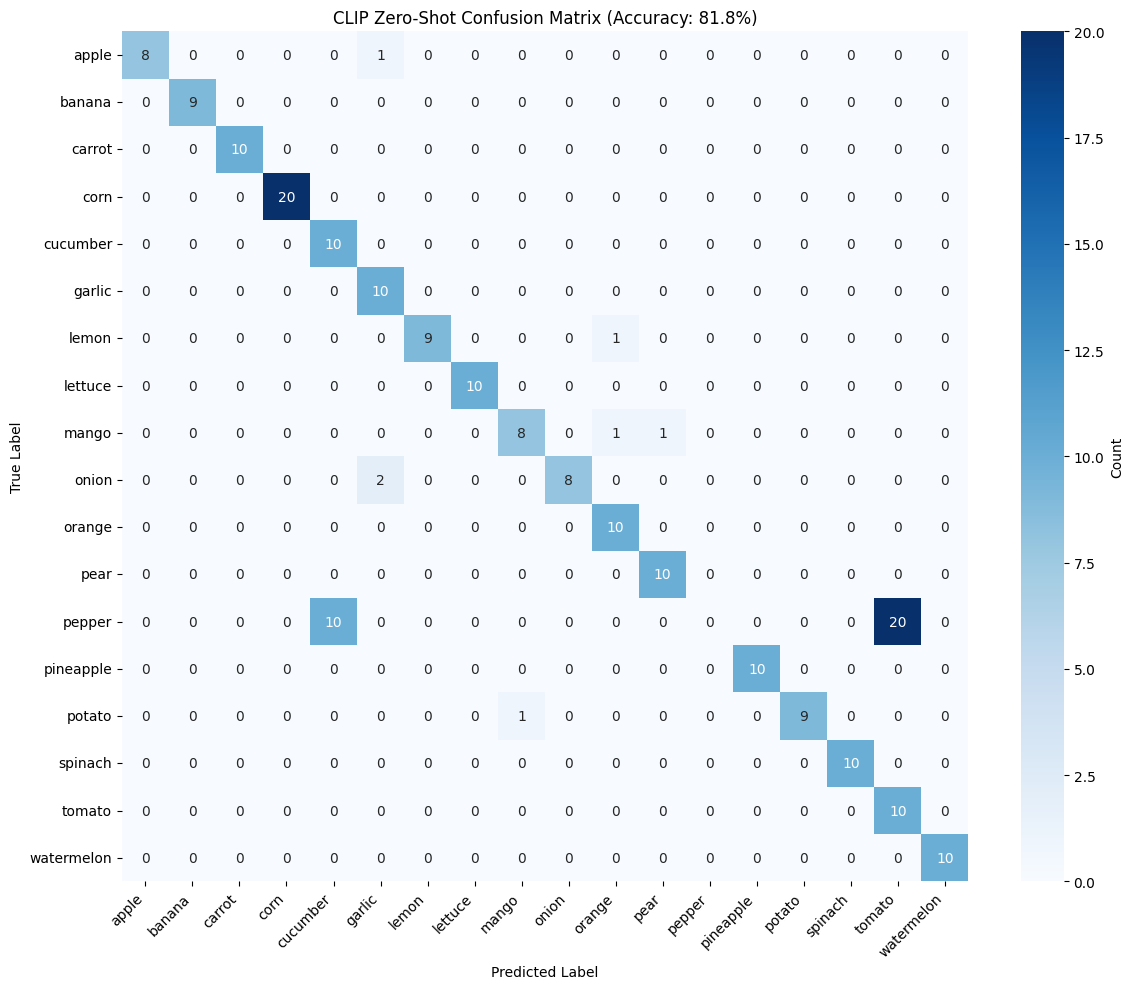

✅ Confusion matrix saved as cv_confusion_matrix.png


In [12]:
cm = confusion_matrix(y_true, y_pred, labels=present_labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels, yticklabels=present_labels,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'CLIP Zero-Shot Confusion Matrix (Accuracy: {accuracy*100:.1f}%)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cv_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved as cv_confusion_matrix.png')

## 8. Error Analysis
Identify which classes CLIP confuses, and inspect the actual misclassified images.

In [13]:
# Build a dataframe of all predictions
results_df = pd.DataFrame({
    'true': y_true,
    'pred': y_pred,
    'confidence': confidences,
    'correct': [t == p for t, p in zip(y_true, y_pred)],
    'path': [s[0] for s in test_samples]
})

# Most common confusion pairs
errors = results_df[~results_df['correct']]
print(f'Total errors: {len(errors)} / {len(results_df)}\n')
print('=== Most common confusion pairs (true -> predicted) ===')
confusion_pairs = errors.groupby(['true', 'pred']).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

# Confidence comparison: correct vs incorrect
print('\n=== Average confidence ===')
print(f"  Correct predictions:   {results_df[results_df['correct']]['confidence'].mean()*100:.1f}%")
print(f"  Incorrect predictions: {results_df[~results_df['correct']]['confidence'].mean()*100:.1f}%")

Total errors: 38 / 209

=== Most common confusion pairs (true -> predicted) ===
true    pred    
pepper  tomato      20
        cucumber    10
onion   garlic       2
apple   cherry       1
        garlic       1
mango   pear         1
        orange       1
lemon   orange       1
potato  mango        1
dtype: int64

=== Average confidence ===
  Correct predictions:   94.0%
  Incorrect predictions: 65.2%


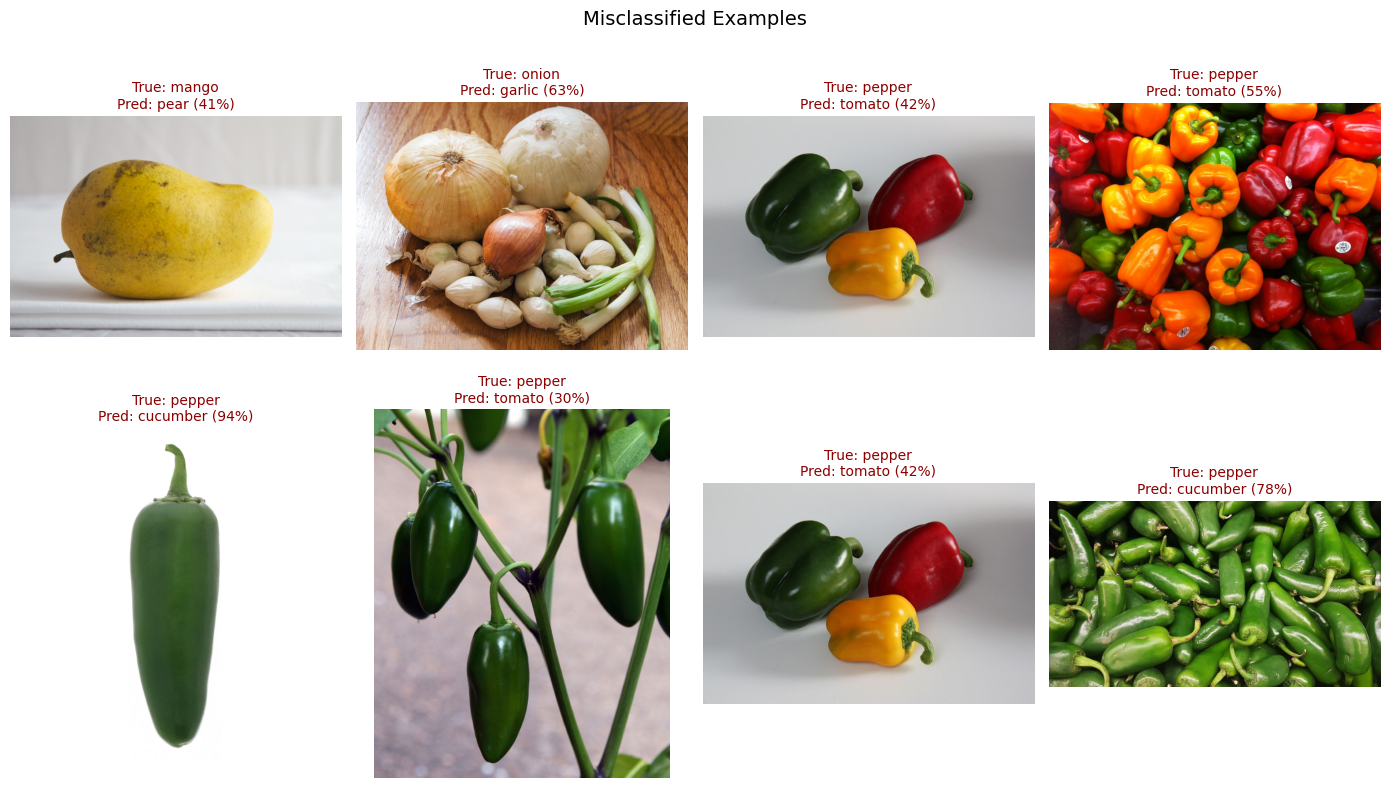

✅ Misclassified examples saved as cv_misclassified.png


In [14]:
# Visualize some misclassified images
n_show = min(8, len(errors))
if n_show > 0:
    sample_errors = errors.sample(n_show, random_state=42)
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4*rows))
    axes = axes.flatten() if n_show > 1 else [axes]

    for ax, (_, row) in zip(axes, sample_errors.iterrows()):
        img = Image.open(row['path']).convert('RGB')
        ax.imshow(img)
        ax.set_title(f"True: {row['true']}\nPred: {row['pred']} ({row['confidence']*100:.0f}%)",
                     fontsize=10, color='darkred')
        ax.axis('off')

    for ax in axes[n_show:]:
        ax.axis('off')

    plt.suptitle('Misclassified Examples', fontsize=14)
    plt.tight_layout()
    plt.savefig('cv_misclassified.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Misclassified examples saved as cv_misclassified.png')
else:
    print('No errors to show – perfect classification!')

## 9. Summary & Findings

### Quantitative Results

| Metric | Value |
| --- | --- |
| Overall Top-1 Accuracy | **81.8%** |
| Number of test images | 209 |
| Number of classes evaluated | 18 |
| Total errors | 38 / 209 |
| Avg. confidence (correct predictions) | **94.0%** |
| Avg. confidence (incorrect predictions) | **65.2%** |
| Most confused pair | pepper → tomato (20 errors) |

### Per-Class Highlights

| Class | Precision | Recall | F1-Score | Assessment |
| --- | --- | --- | --- | --- |
| apple | 1.00 | 0.80 | 0.89 | ✅ Good |
| banana | 1.00 | 1.00 | 1.00 | ✅ Perfect |
| carrot | 1.00 | 1.00 | 1.00 | ✅ Perfect |
| corn | 1.00 | 1.00 | 1.00 | ✅ Perfect |
| cucumber | 0.50 | 1.00 | 0.67 | ⚠️ Weak |
| garlic | 0.77 | 1.00 | 0.87 | ✅ Good |
| lettuce | 1.00 | 1.00 | 1.00 | ✅ Perfect |
| mango | 0.89 | 0.80 | 0.84 | ✅ Good |
| onion | 1.00 | 0.80 | 0.89 | ✅ Good |
| orange | 0.83 | 1.00 | 0.91 | ✅ Good |
| pear | 0.91 | 1.00 | 0.95 | ✅ Good |
| **pepper** | **0.00** | **0.00** | **0.00** | ❌ Fails completely |
| pineapple | 1.00 | 1.00 | 1.00 | ✅ Perfect |
| potato | 1.00 | 0.90 | 0.95 | ✅ Good |
| spinach | 1.00 | 1.00 | 1.00 | ✅ Perfect |
| **tomato** | **0.33** | **1.00** | **0.50** | ❌ Weak |
| watermelon | 1.00 | 1.00 | 1.00 | ✅ Perfect |

### Error Pattern Analysis

**Pattern 1 — Colour/Shape Confusion (dominant error):**  
The most critical failure is **pepper → tomato (20/30 pepper images misclassified)** and **pepper → cucumber (10/30)**.
Both red bell peppers and tomatoes are round and red; both green peppers and cucumbers share colour and elongated shape.
CLIP's Zero-Shot approach relies entirely on pre-trained visual-language associations and has no fine-grained
shape or texture knowledge for these visually overlapping classes.

**Pattern 2 — Confidence as a Reliability Signal:**  
Correct predictions average **94.0% confidence**, while incorrect ones average only **65.2%** — a gap of ~29 percentage points.
This is a valuable finding: a confidence threshold (e.g. flag predictions below 70%) could be implemented
in the app to warn users when the model is uncertain.

**Pattern 3 — Secondary confusions are minor:**  
All other confusion pairs (onion→garlic, apple→cherry, mango→pear, lemon→orange, potato→mango) occur
only 1-2 times each, suggesting CLIP handles most classes robustly.

### Why 81.8% is Strong for a Zero-Shot Model

CLIP was never trained on this specific dataset or these exact class labels. Achieving 81.8% accuracy
without any fine-tuning demonstrates the strength of large vision-language pretraining.
For comparison, a random baseline (1/18 classes) would yield only ~5.6%.
The result also validates the design choice to use CLIP for the deployed app,
which prioritises simplicity and zero-shot generalisation over maximum per-class accuracy.

### Limitations and Possible Improvements

1. **Pepper class completely fails (F1=0.00):** Could be fixed by fine-tuning CLIP on a dedicated
   pepper dataset, or by prompt engineering (e.g. using 'bell pepper' as label instead of 'pepper').
2. **No fine-tuning:** A fine-tuned ViT on this dataset would likely exceed 95%+ accuracy,
   but would require labelled training data and GPU time — not suitable for this project scope.
3. **Label wording matters:** CLIP is sensitive to how labels are phrased. Testing alternative
   phrasings ('bell pepper', 'chili pepper') could improve pepper recall without any retraining.
4. **Test set size:** With 10 images per class, results may have higher variance for rare classes.
   A larger test set (50+ per class) would give more stable estimates.

### Integration with Other Blocks

The CV evaluation directly informs the **ML block's reliability**: since pepper is never correctly
classified, the ML calorie prediction for pepper inputs will always receive a wrong food label
(tomato or cucumber macros instead of pepper macros). This is documented as a known system limitation
in the deployment section. The confidence gap (94% vs 65%) could also be exposed to the user
in the Gradio app as a quality indicator.

In [15]:
# Save the results table for your records
summary = {
    'accuracy': accuracy,
    'n_images': len(results_df),
    'n_classes': len(present_labels),
    'avg_conf_correct': results_df[results_df['correct']]['confidence'].mean(),
    'avg_conf_incorrect': results_df[~results_df['correct']]['confidence'].mean() if len(errors) else None,
}
pd.DataFrame([summary]).to_csv('cv_eval_summary.csv', index=False)
results_df.to_csv('cv_eval_predictions.csv', index=False)
print('✅ Saved cv_eval_summary.csv and cv_eval_predictions.csv')

# Download files (Colab only)
try:
    from google.colab import files
    files.download('cv_confusion_matrix.png')
    if os.path.exists('cv_misclassified.png'):
        files.download('cv_misclassified.png')
    files.download('cv_eval_summary.csv')
    files.download('cv_eval_predictions.csv')
except ImportError:
    print('Not in Colab – files saved locally instead')

✅ Saved cv_eval_summary.csv and cv_eval_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>